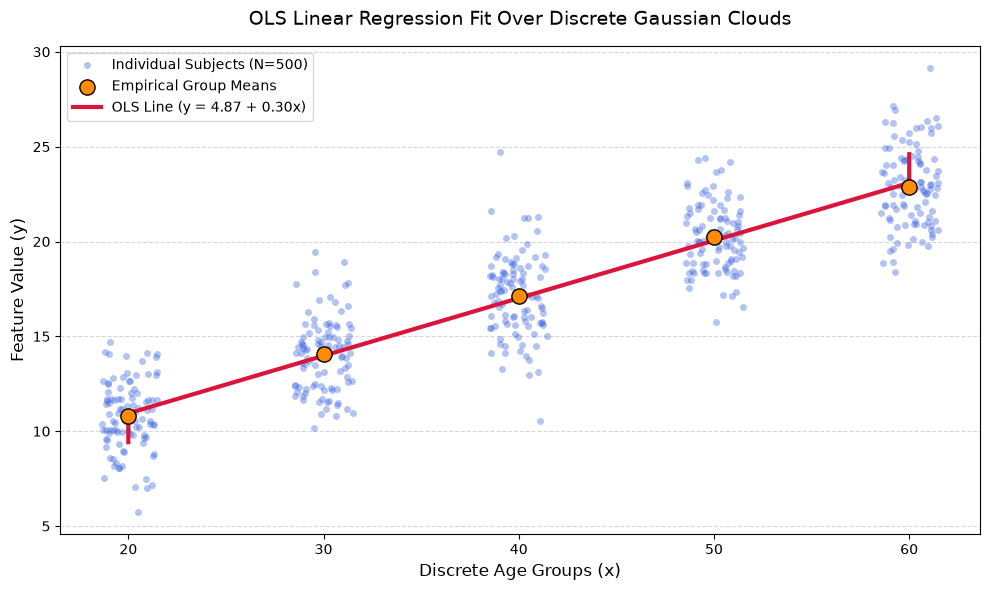

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# 1. Generate the simulated dataset
np.random.seed(42)
discrete_ages = [20, 30, 40, 50, 60]
subjects_per_age = 100

data_rows = []
for age in discrete_ages:
    # Simulating a Gaussian distribution centered at 5 + 0.3 * age
    conditional_mean = 5.0 + 0.3 * age
    y_values = np.random.normal(loc=conditional_mean, scale=2.0, size=subjects_per_age)
    for y in y_values:
        data_rows.append({'Age': age, 'Feature_Value': y})

df = pd.DataFrame(data_rows)

# 2. Fit the OLS model
X = sm.add_constant(df['Age'])
y = df['Feature_Value']
model = sm.OLS(y, X).fit()

# 3. Create the plot
plt.figure(figsize=(10, 6), dpi=100)

# Scatter plot with high transparency to visually showcase point density (Gaussian cloud)
sns.stripplot(
    data=df, 
    x='Age', 
    y='Feature_Value', 
    color='royalblue', 
    alpha=0.4, 
    jitter=0.15, # Jitter spreads points slightly horizontally to reveal density
    label='Individual Subjects (N=500)'
)

# Plot the calculated mean for each group to highlight the distribution centers
group_means = df.groupby('Age')['Feature_Value'].mean()
plt.scatter(
    x=np.arange(len(discrete_ages)), # Maps to the categorical strip slots
    y=group_means, 
    color='darkorange', 
    s=120, 
    zorder=5, 
    edgecolor='black', 
    label='Empirical Group Means'
)

# Plot the final fitted linear regression line
x_line = np.linspace(15, 65, 100)
y_line = model.params['const'] + model.params['Age'] * x_line
# Convert absolute continuous x-axis values to match categorical indices on the plot
x_indices = np.interp(x_line, discrete_ages, np.arange(len(discrete_ages)))

plt.plot(
    x_indices, 
    y_line, 
    color='crimson', 
    linewidth=3, 
    linestyle='-', 
    zorder=4, 
    label=f'OLS Line (y = {model.params["const"]:.2f} + {model.params["Age"]:.2f}x)'
)

# Format chart elements
plt.title('OLS Linear Regression Fit Over Discrete Gaussian Clouds', fontsize=14, pad=15)
plt.xlabel('Discrete Age Groups (x)', fontsize=12)
plt.ylabel('Feature Value (y)', fontsize=12)
plt.xticks(ticks=np.arange(len(discrete_ages)), labels=discrete_ages)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Handle duplicated labels from stripplot loops in legend
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper left')

plt.tight_layout()
plt.show()


In [6]:
participants_df = pd.read_csv("vbm_processing/participants_study_3.tsv", sep="\t")
print(participants_df.head())

   participant_id  split     sex   age diagnosis          tiv        csfv  \
0    100544064116  train  female  15.0   control  1304.233543  206.305238   
1    103116472269  train    male  23.0   control  1396.005006  221.860922   
2    106297012000  train    male  22.0   control  1474.228678  342.927536   
3    106847803341  train    male  10.0   control  1738.841718  344.608421   
4    107012705146  train  female  20.0   control  1389.191914  261.391518   

          gmv         wmv  magnetic_field_strength  acquisition_setting  site  \
0  667.809720  429.723510                      3.0                  1.0     4   
1  695.410262  478.340157                      3.0                  1.0     7   
2  659.530309  471.509967                      3.0                  1.0    18   
3  863.512769  530.529870                      3.0                  1.0    19   
4  634.754153  492.716008                      3.0                  1.0    20   

   study  
0      3  
1      3  
2      3  
3     

In [8]:
age = pd.to_numeric(participants_df["age"], errors="coerce").dropna()
 
n = len(age)
mean, sd = age.mean(), age.std(ddof=1)
med = age.median()
q1, q3 = age.quantile(0.25), age.quantile(0.75)
amin, amax = age.min(), age.max()

print("=== study==3 demographics (n={0}) ===".format(n))
print("age mean +/- SD : {0:.2f} +/- {1:.2f} yr".format(mean, sd))
print("age median [IQR]: {0:.1f} [{1:.1f}-{2:.1f}]".format(med, q1, q3))
print("age range       : {0:.1f}-{1:.1f}".format(amin, amax))

=== study==3 demographics (n=508) ===
age mean +/- SD : 24.27 +/- 15.08 yr
age median [IQR]: 21.0 [16.0-24.0]
age range       : 6.0-83.0


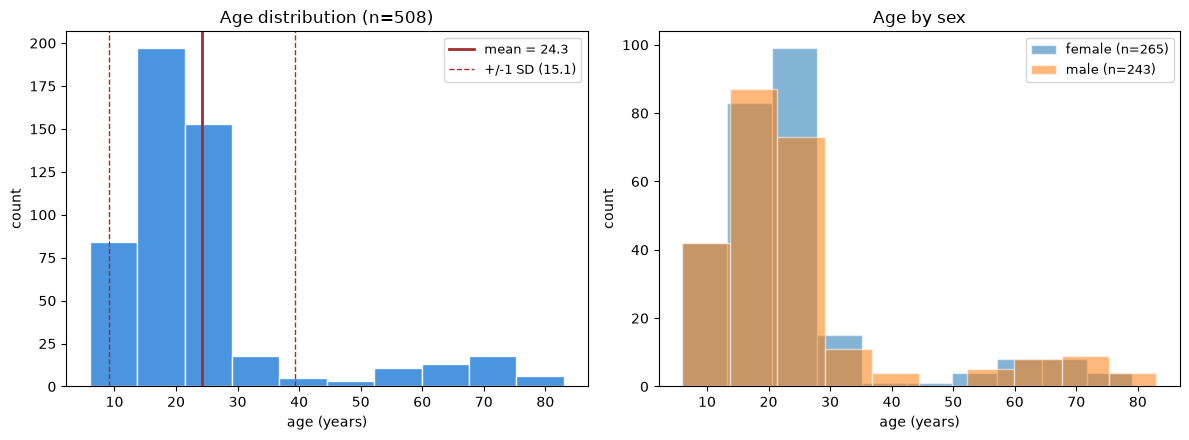

In [11]:
has_sex = "sex" in participants_df.columns
fig, ax = plt.subplots(1, 2 if has_sex else 1,
                           figsize=(12 if has_sex else 6.5, 4.5), squeeze=False)
a0 = ax[0][0]
a0.hist(age, bins=10, color="#378ADD", edgecolor="white", alpha=0.9)
a0.axvline(mean, color="#A32D2D", lw=2, label="mean = {0:.1f}".format(mean))
a0.axvline(mean - sd, color="#A32D2D", lw=1, ls="--",
           label="+/-1 SD ({0:.1f})".format(sd))
a0.axvline(mean + sd, color="#A32D2D", lw=1, ls="--")
a0.set_xlabel("age (years)"); a0.set_ylabel("count")
a0.set_title("Age distribution (n={0})".format(n)); a0.legend(fontsize=9)

if has_sex:
    a1 = ax[0][1]
    for s, g in participants_df.groupby(participants_df["sex"].astype(str)):
        a = pd.to_numeric(g["age"], errors="coerce").dropna()
        a1.hist(a, bins=10, alpha=0.55, edgecolor="white",
                label="{0} (n={1})".format(s, len(a)))
    a1.set_xlabel("age (years)"); a1.set_ylabel("count")
    a1.set_title("Age by sex"); a1.legend(fontsize=9)
 
    fig.tight_layout()
plt.show()

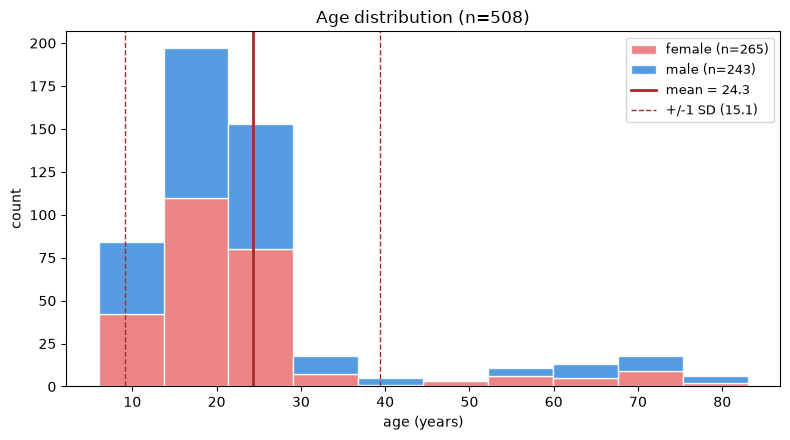

In [33]:
has_sex = "sex" in participants_df.columns

fig, ax = plt.subplots(figsize=(8, 4.5))

if has_sex:
    sex_colors = {"female": "#E87070", "male": "#378ADD"}
    groups = {s: pd.to_numeric(g["age"], errors="coerce").dropna()
              for s, g in participants_df.groupby(participants_df["sex"].astype(str))}
    labels = list(groups.keys())
    data   = [groups[s] for s in labels]
    colors = [sex_colors.get(s, None) for s in labels]

    ax.hist(data, bins=10, stacked=True, color=colors, edgecolor="white", alpha=0.85,
            label=["{0} (n={1})".format(s, len(groups[s])) for s in labels])
else:
    ax.hist(age, bins=10, color="#378ADD", edgecolor="white", alpha=0.9)

ax.axvline(mean, color="#A32D2D", lw=2, label="mean = {0:.1f}".format(mean))
ax.axvline(mean - sd, color="#A32D2D", lw=1, ls="--",
           label="+/-1 SD ({0:.1f})".format(sd))
ax.axvline(mean + sd, color="#A32D2D", lw=1, ls="--")

ax.set_xlabel("age (years)")
ax.set_ylabel("count")
ax.set_title("Age distribution (n={0})".format(n))
ax.legend(fontsize=9)

fig.tight_layout()
plt.show()

In [18]:
import numpy as np
import matplotlib.pyplot as plt

X = np.load("vbm_data_z60/vbm_z60.npy").astype("float32")


for i in range(X.shape[0]):
      print(np.max(X[i,:,:]), np.min(X[i,:,:]), np.mean(X[i,:,:]), np.std(X[i,:,:]))

1.3450981 0.0 0.1451926 0.26833245
1.7254903 0.0 0.16084199 0.29934475
1.482353 0.0 0.14524579 0.2707336
2.0588236 0.0 0.181075 0.33633187
1.372549 0.0 0.13327768 0.25410068
1.6431373 0.0 0.16170253 0.30531138
1.8235295 0.0 0.17931283 0.33657062
1.7137256 0.0 0.16521618 0.30477393
1.3568628 0.0 0.13674328 0.2556184
1.3333334 0.0 0.13168314 0.2555221
1.5960785 0.0 0.15881984 0.30028522
1.4588236 0.0 0.1502912 0.2759911
1.4000001 0.0 0.12903583 0.24198806
1.9058825 0.0 0.18895613 0.3545199
1.3450981 0.0 0.14087072 0.26360303
1.5215688 0.0 0.14204013 0.27012616
1.6313727 0.0 0.16662902 0.317778
1.3843138 0.0 0.12362096 0.23754378
1.2588236 0.0 0.12767103 0.23737556
1.6235296 0.0 0.15719512 0.29038766
1.3686275 0.0 0.10642684 0.21163255
1.4470589 0.0 0.14044133 0.26276553
1.309804 0.0 0.13325176 0.2521641
1.7529413 0.0 0.17170347 0.3148317
1.3058825 0.0 0.13564047 0.2560924
1.6509805 0.0 0.16804811 0.31165838
1.372549 0.0 0.1447554 0.27648664
1.3333334 0.0 0.12947927 0.24906397
1.5333334 0

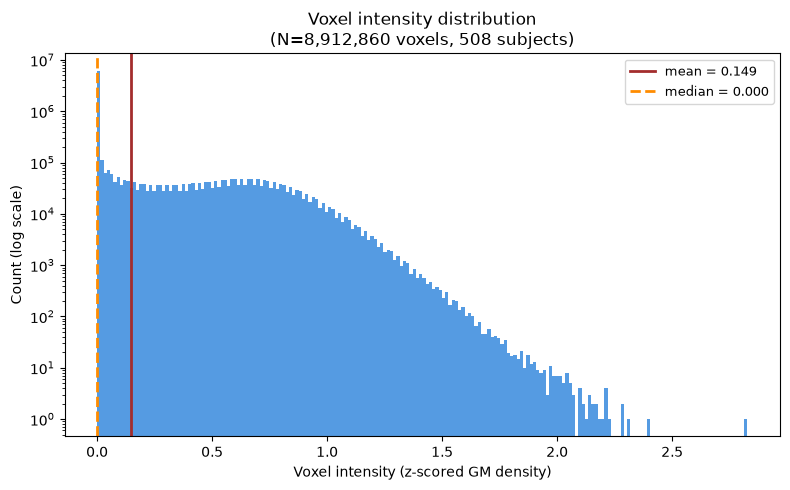

Shape : (508, 121, 145)
Min   : 0.0000
Max   : 2.8275
Mean  : 0.1488
Std   : 0.2819
Frac == 0 : 0.674  (likely out-of-brain voxels)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load data: shape (508, 121, 145)
panels = [
    ("vbm_data_sliced/vbm_z60.npy", "z = 60 (axial)"),
    ("vbm_data_sliced/vbm_z40.npy", "z = 40 (axial)"),
    ("vbm_data_sliced/vbm_y80.npy", "y = 80 (coronal)"),
]


# Flatten all voxel values across all subjects
voxels = X.ravel()

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(voxels, bins=200, color="#378ADD", edgecolor="none", alpha=0.85, log=True)
ax.axvline(voxels.mean(), color="#A32D2D", lw=2,
           label=f"mean = {voxels.mean():.3f}")
ax.axvline(np.median(voxels), color="darkorange", lw=2, ls="--",
           label=f"median = {np.median(voxels):.3f}")
ax.set_xlabel("Voxel intensity (z-scored GM density)")
ax.set_ylabel("Count (log scale)")
ax.set_title(f"Voxel intensity distribution\n(N={len(voxels):,} voxels, 508 subjects)")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Quick stats
print(f"Shape : {X.shape}")
print(f"Min   : {voxels.min():.4f}")
print(f"Max   : {voxels.max():.4f}")
print(f"Mean  : {voxels.mean():.4f}")
print(f"Std   : {voxels.std():.4f}")
print(f"Frac == 0 : {(voxels == 0).mean():.3f}  (likely out-of-brain voxels)")

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# Datasets
panels = [
    ("vbm_data_sliced/vbm_z60.npy", "z = 60 (axial)"),
    ("vbm_data_sliced/vbm_z40.npy", "z = 40 (axial)"),
    ("vbm_data_sliced/vbm_y80.npy", "y = 80 (coronal)"),
]

# Load data and flatten voxels
all_voxels = []
max_count = 0
bins = 200

for path, _ in panels:
    X = np.load(path)
    voxels = X.ravel()
    all_voxels.append(voxels)

    # Compute histogram counts for common y-axis scaling
    counts, _ = np.histogram(voxels, bins=bins)
    max_count = max(max_count, counts.max())

# Create 3x1 grid with shared y-axis
fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(8, 12),
    sharey=True
)

for ax, (path, title), voxels in zip(axes, panels, all_voxels):

    mean_val = voxels.mean()
    median_val = np.median(voxels)

    ax.hist(
        voxels,
        bins=bins,
        color="#378ADD",
        edgecolor="none",
        alpha=0.85,
        log=True
    )

    ax.axvline(
        mean_val,
        color="#A32D2D",
        lw=2,
        label=f"mean = {mean_val:.3f}"
    )

    ax.axvline(
        median_val,
        color="darkorange",
        lw=2,
        ls="--",
        label=f"median = {median_val:.3f}"
    )

    ax.set_title(title)
    ax.legend(fontsize=8)

# Common axis labels
axes[-1].set_xlabel("Voxel intensity (z-scored GM density)")
fig.supylabel("Count (log scale)")

# Force identical y-axis limits
for ax in axes:
    ax.set_ylim(1, max_count * 1.2)

plt.tight_layout()
plt.savefig("vbm_processing/voxel_intensity_distributions.png", dpi=300, bbox_inches="tight")
plt.close()

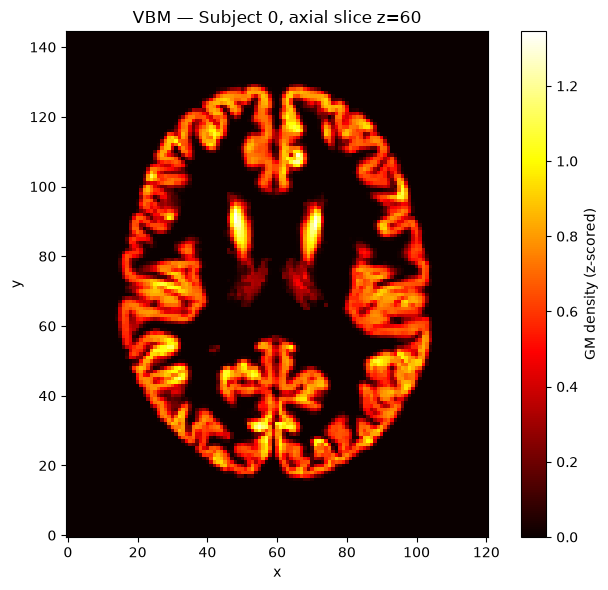

In [29]:
slice_z60 = X[0]  # shape (121, 145) — first subject, z=60

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(slice_z60.T, origin="lower", cmap="hot", aspect="equal")
plt.colorbar(im, ax=ax, label="GM density (z-scored)")
ax.set_title("VBM — Subject 0, axial slice z=60")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()
plt.show()